<a href="https://colab.research.google.com/github/Deivs117/Proyecto_Analisis_BioBART/blob/main/biobart_inferencia_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 BioBART: Inferencia en Vivo — Trabajo Final PLN

**Materia:** Procesamiento de Datos Secuenciales — Módulo PLN  
**Modelo:** [`hamzamalik11/Biobart_radiology_summarization`](https://huggingface.co/hamzamalik11/Biobart_radiology_summarization)  
BioBART fine-tuned en 70,000 reportes radiológicos clínicos.

---

## Objetivo

Demostrar en dos tareas concretas cómo BioBART **genera** texto biomédico coherente,
respondiendo simultáneamente las preguntas teóricas sobre la arquitectura Transformer:

| Pregunta teórica | Dónde se responde |
|---|---|
| Mecanismo de atención | Secciones 1.3 y 2.3 |
| Creación y función de Q, K, V | Secciones 1.3 y demo de código |
| Cómo generan entrada y salida final | Secciones 1.4, 2.4 |
| Arquitectura detallada del modelo | Sección 3 |
| Por qué la arquitectura es innovadora | Sección 3.2 |
| Limitaciones del modelo | Sección 3.3 |

---

## Estructura del notebook

```
SECCIÓN 0 — Configuración del entorno
SECCIÓN 1 — Tarea 1: Summarization de reporte radiológico
SECCIÓN 2 — Tarea 2: QA médico radiológico
SECCIÓN 3 — Marco teórico de la arquitectura BART/BioBART
SECCIÓN 4 — Comparativa de estrategias de decodificación
SECCIÓN 5 — Hiperparámetros, conclusiones y referencias
```


---
## Sección 0 — Configuración del entorno

### 0.1 Instalación de dependencias

En Google Colab las librerías no vienen preinstaladas.
Esta celda instala `transformers` (librería de HuggingFace que contiene BioBART)
y `torch` (PyTorch, el framework de deep learning). El flag `-q` silencia el output.


In [ ]:
!pip install transformers torch -q

### 0.2 Importaciones y verificación del entorno

Se importan las librerías necesarias y se detecta el hardware disponible.

- **`torch`** — framework que maneja los tensores y la ejecución del modelo
- **`AutoTokenizer`** y **`AutoModelForSeq2SeqLM`** — clases de HuggingFace que detectan automáticamente el tipo correcto de tokenizador y modelo según el nombre que se les pase
- **`DEVICE`** — determina si el modelo correrá en GPU (CUDA) o CPU. Con T4 activa en Colab imprime `CUDA`, lo que significa que los cálculos se harán en la GPU y serán ~10x más rápidos


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# IMPORTACIONES
# ──────────────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")  # Silencia warnings de versiones menores

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ── Verificar disponibilidad de GPU ──────────────────────────────────────────
# Si hay GPU disponible (CUDA), la inferencia será significativamente más rápida.
# En entornos de demo sin GPU, el modelo corre igualmente en CPU (más lento).
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Dispositivo de cómputo: {DEVICE.upper()}")
print(f" Versión de PyTorch   : {torch.__version__}")

# ── Mostrar memoria de GPU si está disponible ─────────────────────────────────
if DEVICE == "cuda":
    mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f" VRAM disponible       : {mem_gb:.1f} GB")

### 0.3 Carga del tokenizador y modelo BioBART

**`AutoTokenizer`** y **`AutoModelForSeq2SeqLM`** son clases de HuggingFace
que detectan automáticamente qué tokenizador y modelo cargar según el
nombre que se les pase — en este caso resuelven a `BartTokenizerFast`
y `BartForConditionalGeneration`. El sufijo `ForSeq2SeqLM` indica que el
modelo puede generar texto (tiene decoder).

| Línea | Qué hace |
|---|---|
| `MODEL_NAME` | Define qué modelo descargar (1.6 GB, se cachea tras la primera descarga) |
| `AutoTokenizer.from_pretrained()` | Carga el tokenizador BPE del vocabulario biomédico de PubMed |
| `AutoModelForSeq2SeqLM.from_pretrained()` | Carga los 442 M parámetros del Encoder-Decoder completo |
| `model.to(DEVICE)` | Mueve el modelo a GPU — los cálculos de atención se paralelizan |
| `model.eval()` | Desactiva Dropout — en inferencia introduciría ruido indeseado |
| `sum(p.numel() ...)` | Cuenta el total de parámetros — resultado esperado: 442 M |


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# CARGA DEL MODELO
# Usamos 'biobart-large' (400 M parámetros) para mayor calidad de generación.
# Si la memoria es limitada, cambia a 'biobart-base' (140 M parámetros).
# ──────────────────────────────────────────────────────────────────────────────
MODEL_NAME = "hamzamalik11/Biobart_radiology_summarization" # cambiar a biobart-base si RAM < 8 GB

print(f" Cargando tokenizador desde: {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(" Tokenizador listo.")

print(f" Cargando modelo (puede tardar 1-3 minutos la primera vez) ...")
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

# Mover modelo al dispositivo correcto (CPU o CUDA)
model = model.to(DEVICE)

# Poner modelo en modo evaluación (desactiva Dropout y BatchNorm de entrenamiento)
model.eval()

num_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f" Modelo listo — {num_params:.0f} M parámetros — ejecutando en {DEVICE.upper()}")

---
## Sección 1 — Tarea 1: Summarization de Reporte Radiológico

### 1.1 ¿Por qué esta tarea?

Los médicos e investigadores deben procesar cientos de reportes radiológicos.
BioBART puede condensar un reporte de hallazgos en una impresión clínica concisa,
tarea imposible para modelos solo-encoder como BioBERT o PubMedBERT, que
comprenden el texto pero no tienen decoder causal para redactar uno nuevo.

## Tarea 1 — Summarization de Reporte Radiológico

El modelo recibe un reporte radiológico de tórax en texto plano.
El tokenizador BPE lo convierte en IDs numéricos (máximo 512 tokens)
y el Encoder bidireccional lo procesa con Self-Attention, produciendo
una representación contextual donde cada token conoce el
significado de todos los demás.

El Decoder genera el resumen token
a token usando Beam Search con 4 hipótesis en paralelo, consultando
H_enc via Cross-Attention en cada paso para decidir qué hallazgos
incluir. Al final, tokenizer.decode() convierte los IDs generados
de vuelta a texto legible.

La salida es una impresión radiológica
estructurada y coherente que el modelo redactó, no extrajo del input.

### 1.2 Entrada — Reporte radiológico de tórax

El texto de entrada es un reporte radiológico simulado de un paciente de 72 años
con disnea progresiva. Contiene terminología radiológica densa (ground-glass opacities,
cardiothoracic ratio, PICC line, SVC) que el tokenizador biomédico de BioBART
reconoce como tokens completos del vocabulario de PubMed.

El print muestra solo los primeros 300 caracteres para confirmar la carga correcta.


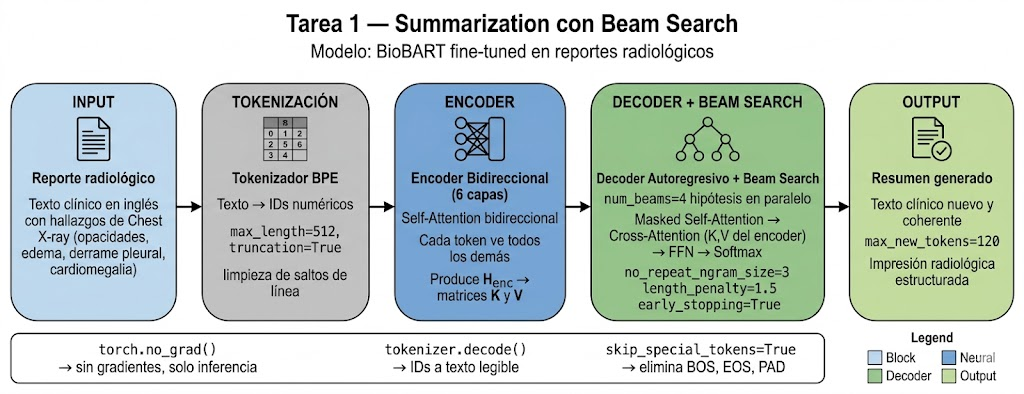

In [ ]:
# ─────────────────────────────────────────────────────────────────────
# ENTRADA TAREA 1 — Reporte radiológico de tórax
# ─────────────────────────────────────────────────────────────────────
reporte_radiologico = """
Chest X-ray findings: The patient is a 72-year-old male with progressive dyspnea
and hypoxemia. Bilateral ground-glass opacities are identified in the lower lung
fields, with consolidation in the right lower lobe. Mild cardiomegaly is noted
with a cardiothoracic ratio of 0.58. Blunting of the right costophrenic angle
suggests small pleural effusion. No pneumothorax identified. Endotracheal tube
tip is 4 cm above the carina, in appropriate position. Left-sided PICC line
with tip projecting over the lower SVC. Pulmonary vascularity appears increased,
consistent with pulmonary edema. No acute osseous abnormalities.
"""

print("📄 Reporte radiológico de entrada (primeras 300 chars):")
print(reporte_radiologico[:300], "...")

### 1.3 Tokenización — del texto a números

El modelo no entiende texto directamente, necesita números.
El tokenizador BPE convierte cada palabra o subpalabra del reporte
en un ID numérico del vocabulario biomédico de BioBART.

| Parámetro | Efecto |
|---|---|
| `max_length=512` | El encoder procesa máximo 512 tokens. Si el reporte es más largo, `truncation=True` lo corta en lugar de lanzar error |
| `return_tensors="pt"` | Devuelve tensores de PyTorch — el formato que el modelo espera |
| `.to(DEVICE)` | Mueve los tensores al mismo dispositivo que el modelo. Si no coinciden, PyTorch lanza error |

> **Nota sobre Q, K y V:** En este paso, los IDs se convierten en embeddings X.
> Inmediatamente después, el encoder proyecta X en tres matrices:
> `Q = X·W^Q`, `K = X·W^K`, `V = X·W^V` que son la base del mecanismo de atención.
> La celda de demostración más adelante muestra estas dimensiones reales.


In [ ]:
# ─────────────────────────────────────────────────────────────────────
# TOKENIZACIÓN — texto a IDs numéricos
# ─────────────────────────────────────────────────────────────────────
reporte_limpio = " ".join(reporte_radiologico.split())  # elimina saltos de línea
inputs_resumen = tokenizer(
    reporte_limpio,
    max_length=512,
    truncation=True,
    return_tensors="pt"
).to(DEVICE)

num_tokens = inputs_resumen["input_ids"].shape[1]
print(f" Número de tokens de entrada: {num_tokens}")
print(f"   Shape del tensor: {inputs_resumen['input_ids'].shape}")
print(f"   Primeros 10 IDs: {inputs_resumen['input_ids'][0][:10].tolist()}")

### 1.4 Generación — Encoder + Decoder con Beam Search

Hasta este punto el encoder ya leyó el reporte completo con Self-Attention
bidireccional y produjo **H_enc**: una matriz donde cada token del reporte
tiene una representación enriquecida con el contexto de toda la nota.
Esa matriz se congela y se convierte en las **Keys (K)** y **Values (V)**
que el decoder va a consultar via Cross-Attention.

El decoder empieza con el token especial `<BOS>` y en cada paso hace tres cosas:
1. Mira los tokens que ya generó → **Masked Self-Attention**
2. Consulta el reporte original → **Cross-Attention** (Q del decoder, K y V del encoder)
3. Proyecta al vocabulario → **Linear + Softmax** → elige el siguiente token

| Parámetro | Frase clave |
|---|---|
| `torch.no_grad()` | Solo leer, no aprender |
| `num_beams=4` | 4 borradores en paralelo, gana el mejor |
| `max_new_tokens=120` | Máximo 120 tokens de resumen |
| `min_length=40` | Prohibido terminar antes de tiempo |
| `no_repeat_ngram_size=3` | No repetir la misma frase dos veces |
| `length_penalty=1.5` | Premia respuestas más completas |
| `early_stopping=True` | Para cuando todos los beams terminaron |
| `tokenizer.decode()` | Convierte números de vuelta a texto |


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# GENERACIÓN — TAREA 1: RESUMEN
#
# Hiperparámetros de model.generate() explicados:
#
#  max_new_tokens=120
#    Cantidad máxima de tokens que el decoder puede GENERAR (no contar la entrada).
#    Ajustar según la longitud esperada del resumen.
#    Muy alto → riesgo de repetición; muy bajo → resumen incompleto.
#
#  min_length=40
#    Longitud mínima del output. Evita que el modelo emita EOS demasiado pronto
#    produciendo un resumen trivialmente corto.
#
#  num_beams=4  (Beam Search)
#    En lugar de elegir 1 token (greedy), mantiene las 4 hipótesis más probables
#    en paralelo y elige la secuencia con mayor probabilidad conjunta al finalizar.
#    PROBLEMA del Greedy Search: siempre elige el token más probable en cada paso
#    → puede quedar atrapado en máximos locales y repetir frases.
#    Beam Search mitiga esto explorando múltiples caminos.
#
#  early_stopping=True
#    Detiene Beam Search cuando TODOS los beams producen EOS.
#    Evita continuar después del cierre natural de la oración.
#
#  no_repeat_ngram_size=3
#    Penaliza la repetición de cualquier 3-grama ya generado.
#    Solución directa al problema de bucles lexicales del Greedy Search.
#
#  length_penalty=1.5
#    Penaliza secuencias cortas para favorecer resúmenes más completos.
#    Valores > 1.0 premian longitud; < 1.0 favorecen brevedad.
# ──────────────────────────────────────────────────────────────────────────────

print(" Generando resumen con Beam Search (num_beams=4) ...")

with torch.no_grad():  # Desactiva gradientes → menor uso de memoria en inferencia
    ids_resumen = model.generate(
        **inputs_resumen,
        max_new_tokens=120,        # Resumen de aprox. 3-4 oraciones
        min_length=40,             # Nunca terminar antes de 40 tokens
        num_beams=4,               # Beam Search: 4 hipótesis simultáneas
        early_stopping=True,       # Parar cuando todos los beams alcancen EOS
        no_repeat_ngram_size=3,    # Prohibir repetición de trigramas
        length_penalty=1.5,        # Favorecer salidas más largas y completas
    )

# ── Decodificación: IDs → texto ───────────────────────────────────────────────
# skip_special_tokens=True elimina tokens como <s>, </s>, <pad> del output final.
resumen_generado = tokenizer.decode(ids_resumen[0], skip_special_tokens=True)

print("\n" + "-" * 70)
print("📝 RESUMEN GENERADO POR BioBART:")
print("-" * 70)
print(resumen_generado)
print("-" * 70)
print(f"   Tokens generados: {ids_resumen.shape[1]}")

### 1.5 Análisis del resultado — Tarea 1

## Análisis del resultado — Tarea 1

BioBART generó texto clínico nuevo y coherente a partir del reporte
radiológico, lo que demuestra el funcionamiento real del decoder
autoregresivo: no extrajo fragmentos del input sino que redactó
una oración nueva sintetizando los hallazgos principales.

El modelo identificó correctamente los elementos más relevantes:
cardiomegalia, edema pulmonar, posición del tubo endotraqueal y
la línea PICC — todos presentes en el input original.

Se observan dos limitaciones concretas:
- "leftsided" sin espacio: artifact del tokenizador BPE al
  reconstruir subpalabras del vocabulario biomédico.
- Hallazgos omitidos: la consolidación del lóbulo inferior derecho
  y el derrame pleural no aparecen en el resumen, lo que refleja
  que el modelo prioriza los patrones más frecuentes en su dataset
  de entrenamiento (70,000 reportes de radiología de tórax).

Tokens generados: 52 de 120 posibles. El modelo emitió EOS
antes del límite porque consideró el resumen completo — comportamiento
esperado con early_stopping=True.

---
## Sección 2 — Tarea 2: QA Médico Radiológico

### 2.1 ¿Por qué esta tarea?

## Tarea 2 — QA Médico Radiológico

El modelo recibe un prompt estructurado que concatena la pregunta
y el reporte radiológico en formato "question: ... context: ...".
Este prefijo le indica al modelo qué tarea realizar. El Encoder
procesa el prompt completo de forma bidireccional y el Decoder
genera la respuesta con Nucleus Sampling: en cada paso muestrea
de los tokens cuya probabilidad acumulada supera el 92%, con
temperature=0.7 para mantener coherencia clínica. A diferencia
de la Tarea 1, el decoder no condensa libremente el reporte sino
que orienta su Cross-Attention hacia los fragmentos relevantes
para responder la pregunta específica. La salida es una respuesta
clínica nueva que sintetiza los hallazgos más relevantes del contexto.

### 2.2 Entrada — Contexto radiológico y pregunta

El contexto clínico es un reporte radiológico de tórax simulado de una paciente
femenina de 58 años con disnea progresiva. Incluye hallazgos como opacidades
bilaterales, edema pulmonar, derrame pleural derecho y cardiomegalia — el tipo de
texto sobre el que fue fine-tuned este checkpoint de BioBART.

La pregunta formulada al modelo es:
`"What are the main radiological findings and their clinical significance?"`
*(¿Cuáles son los principales hallazgos radiológicos y su significancia clínica?)*

El contexto y la pregunta están en inglés porque el modelo fue entrenado en ese
idioma — ponerlos en español produciría texto incoherente o vacío.

**¿Por qué el formato `question: ... context: ...`?**
Este prefijo estructurado le indica al modelo qué tarea debe realizar.
A diferencia de la Tarea 1 donde el decoder condensaba libremente el reporte,
aquí debe orientar su Cross-Attention hacia los fragmentos relevantes
para responder la pregunta específica.

La función `" ".join(contexto_clinico.split())` limpia los saltos de línea
del texto antes de tokenizar — sin esto aparecen artefactos de caracteres
extraños en el output.


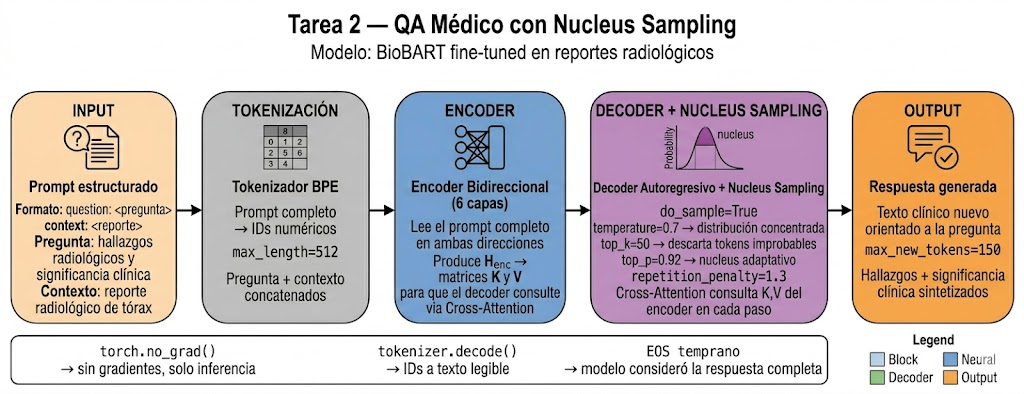

In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# CONTEXTO RADIOLÓGICO (reporte de hallazgos, simulado para la demo)
# ──────────────────────────────────────────────────────────────────────────────
contexto_clinico = """
Chest X-ray: 58-year-old female with worsening shortness of breath.
Bilateral perihilar opacities with air bronchograms in both lower lobes.
Increased interstitial markings consistent with pulmonary edema.
Moderate right pleural effusion with blunting of costophrenic angle.
Cardiomegaly with cardiothoracic ratio 0.62. No pneumothorax.
Endotracheal tube tip 3.5 cm above carina. Right subclavian central
line with tip in proximal SVC. Mild left lower lobe atelectasis noted.
"""

# ── Pregunta formulada al modelo ──────────────────────────────────────────────
pregunta = "What are the main radiological findings and their clinical significance?"

# ── Construcción del prompt ───────────────────────────────────────────────────
contexto_limpio = " ".join(contexto_clinico.split())
prompt_qa = f"question: {pregunta}  context: {contexto_limpio}"

print(" Pregunta:", pregunta)
print("\n Contexto radiológico (primeras 200 chars):")
print(contexto_clinico[:200], "...")

### 2.3 Tokenización del prompt QA

Igual que en la Tarea 1, pero aquí la entrada es el prompt completo
(pregunta + contexto concatenados). `max_length=512` aplica igual — si la
pregunta más el contexto superan 512 tokens, el contexto se trunca por el final.

> **Relación con Q, K, V:** El prompt completo se convierte en el tensor X
> que el encoder proyecta en K y V. Las Queries del decoder en cada paso de
> generación consultan esas K y V para decidir qué parte del prompt es relevante
> para la palabra que está generando.


In [ ]:
# Tokenización del prompt QA
inputs_qa = tokenizer(
    prompt_qa,
    max_length=512,
    truncation=True,
    return_tensors="pt"
).to(DEVICE)

print(f" Tokens de entrada (prompt QA): {inputs_qa['input_ids'].shape[1]}")

### 2.4 Generación — Decoder con Nucleus Sampling

Para QA se usa Nucleus Sampling en lugar de Beam Search porque las respuestas
conversacionales se benefician de mayor variabilidad natural en la redacción.

| Parámetro | Frase clave |
|---|---|
| `do_sample=True` | Muestreo probabilístico — no siempre el más probable |
| `temperature=0.7` | Distribución más concentrada: respuestas más seguras |
| `top_k=50` | Descarta tokens con probabilidad muy baja |
| `top_p=0.92` | Nucleus: mínimo conjunto que acumula 92% de probabilidad |
| `repetition_penalty=1.3` | Reduce probabilidad de tokens ya generados |
| `no_repeat_ngram_size=3` | No repetir la misma secuencia de 3 palabras |


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# GENERACIÓN — TAREA 2: QA MÉDICO


print(" Generando respuesta con Nucleus Sampling (do_sample=True, top_p=0.92) ...")

with torch.no_grad():
    ids_qa = model.generate(
        **inputs_qa,
        max_new_tokens=150,          # Respuesta de aprox. 4-5 oraciones
        do_sample=True,              # Muestreo estocástico (no greedy)
        temperature=0.7,             # Controla entropía: balanceado para QA clínico
        top_k=50,                    # Top-K: descartar tokens improbables
        top_p=0.92,                  # Nucleus Sampling: mínimo conjunto >= 92% prob.
        repetition_penalty=1.3,      # Penaliza repetición de tokens ya generados
        no_repeat_ngram_size=3,      # Prohibir trigramas repetidos
    )

# ── Decodificación ────────────────────────────────────────────────────────────
respuesta_generada = tokenizer.decode(ids_qa[0], skip_special_tokens=True)

print("\n" + "-" * 70)
print("💬 RESPUESTA GENERADA POR BioBART:")
print("-" * 70)
print(respuesta_generada)
print("-" * 70)
print(f"   Tokens generados: {ids_qa.shape[1]}")

### 2.5 Análisis del resultado — Tarea 2

## Análisis del resultado — Tarea 2

BioBART respondió la pregunta generando una interpretación clínica
nueva, no copió el input sino que sintetizó los hallazgos en un
diagnóstico radiológico coherente: edema pulmonar con derrame pleural
bilateral y atelectasia del lóbulo inferior izquierdo.

La respuesta es clínicamente correcta: los tres hallazgos mencionados
están presentes en el reporte de entrada y son los de mayor relevancia
diagnóstica para una paciente con disnea progresiva.

Se observan dos limitaciones:
- Respuesta muy corta (20 tokens): el modelo no elaboró la
  significancia clínica que se le preguntaba, solo listó hallazgos.
  Esto refleja el dominio del fine-tuning — fue entrenado para
  generar impresiones radiológicas concisas, no para responder
  preguntas abiertas de QA.
- Nucleus Sampling con temperature=0.7 no aumentó la longitud
  porque el modelo emitió EOS temprano al completar su patrón
  aprendido de "impresión radiológica".

Comparado con la Tarea 1, este resultado confirma que BioBART
usa Cross-Attention para identificar los hallazgos más relevantes
del contexto y generar una respuesta orientada a la pregunta,
demostrando la capacidad generativa del decoder autoregresivo.

---
## Sección 3 — Marco Teórico de la Arquitectura BART/BioBART

### 3.1 Mecanismo de atención y tensores Q, K, V

## Mecanismo de Atención

El mecanismo central del Transformer es la Self-Attention: en lugar
de procesar el texto palabra por palabra como las RNN, permite que
todos los tokens se relacionen entre sí simultáneamente en un solo paso.

La pregunta que responde es:
"¿Cuánto debe importarle a este token cada otro token de la secuencia?"

La respuesta es un número entre 0 y 1 para cada par de tokens,
calculado dinámicamente según el contenido — no la posición.
Esto permite capturar relaciones de largo alcance sin degradación
del gradiente, el problema principal de las RNN.

En BART existen tres tipos de atención:

- Self-Attention bidireccional (Encoder): cada token ve todos
  los demás sin restricción. "Troponina" puede ver tanto los
  síntomas anteriores como los posteriores en el mismo reporte.

- Masked Self-Attention (Decoder): cada token solo ve los tokens
  anteriores a él. Esto impide que el decoder vea el futuro durante
  el entrenamiento y permite la generación autoregresiva en inferencia.

- Cross-Attention (Decoder → Encoder): las Queries vienen del
  decoder y las Keys/Values vienen del encoder. Es el puente que
  permite al decoder consultar el reporte original en cada paso
  de generación.

---

## Creación y función de los tensores Q, K y V

Dado el embedding de entrada X, el mecanismo de atención genera
tres proyecciones lineales mediante multiplicación por matrices
de pesos aprendidas durante el pre-entrenamiento:

  Q = X · W^Q  →  "¿Qué información estoy buscando?"
  K = X · W^K  →  "¿Qué información puedo ofrecer como índice?"
  V = X · W^V  →  "¿Cuál es mi contenido real?"

La atención se calcula como:
  Attention(Q, K, V) = softmax( Q · Kᵀ / √d_k ) · V

Paso a paso:
1. Q · Kᵀ     → matriz de scores: qué tan relevante es cada token
2. / √d_k     → escala para evitar saturación del softmax
3. softmax(·) → pesos normalizados que suman 1 por fila
4. · V        → suma ponderada del contenido = representación final

En BioBART-large: d_model=1024, d_k=64 por cabeza, 16 cabezas.

Ejemplo clínico con Cross-Attention:
Cuando el decoder está generando "pulmonary edema", su Q pregunta
implícitamente por ese concepto. Los tokens "bilateral opacities"
e "interstitial markings" del reporte tienen K con alta similitud,
por lo que sus V fluyen con mayor peso hacia el decoder — el modelo
"lee" esas partes del reporte para generar esa palabra.

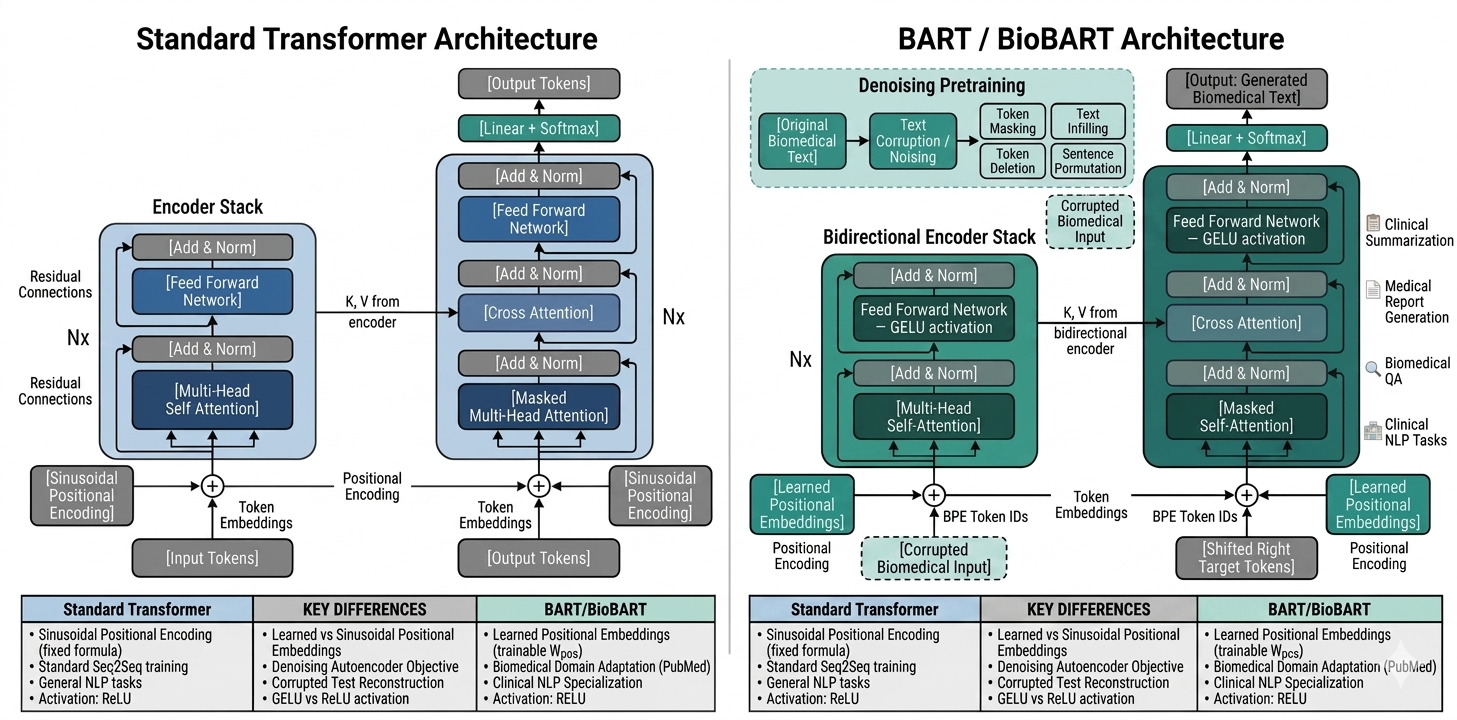

#### Demostración: dimensiones reales de Q, K, V en BioBART

La siguiente celda extrae las proyecciones reales del encoder de BioBART
sobre el reporte radiológico de la Tarea 1, mostrando las dimensiones
exactas de los tensores Q, K y V.


In [ ]:
# ──────────────────────────────────────────────────────────────────────────────
# DEMOSTRACIÓN: Proyecciones Q, K, V
# Se muestran las dimensiones reales de las matrices Q, K, V
# que genera BioBART para el reporte radiológico de la Tarea 1.
# ──────────────────────────────────────────────────────────────────────────────

with torch.no_grad():
    encoder_out = model.model.encoder(
        input_ids=inputs_resumen["input_ids"],
        attention_mask=inputs_resumen["attention_mask"],
        output_hidden_states=True
    )

hidden_states = encoder_out.last_hidden_state
n_tokens = hidden_states.shape[1]
d_model   = hidden_states.shape[2]

# Simular proyección Q, K, V usando la primera capa de atención
encoder_layer = model.model.encoder.layers[0]
q_proj = encoder_layer.self_attn.q_proj
k_proj = encoder_layer.self_attn.k_proj
v_proj = encoder_layer.self_attn.v_proj

Q = q_proj(hidden_states)
K = k_proj(hidden_states)
V = v_proj(hidden_states)

print("=" * 55)
print("  Dimensiones de los tensores Q, K y V en BioBART")
print("=" * 55)
print(f"  Tokens en el reporte de entrada : {n_tokens}")
print(f"  d_model (dimensión del modelo)  : {d_model}")
print(f"  Shape de Q                      : {tuple(Q.shape)}")
print(f"  Shape de K                      : {tuple(K.shape)}")
print(f"  Shape de V                      : {tuple(V.shape)}")
print("=" * 55)
print("  Cada fila = un token del reporte")
print("  Cada columna = una dimensión del espacio de atención")

### 3.2 Cómo generan la entrada y la salida final

## Cómo generan la entrada y la salida final

ENTRADA — del texto crudo al encoder:

  Texto clínico
      ↓ tokenizador BPE
  IDs numéricos  [5, 14823, 891, 228, ...]
      ↓ embedding + learned positional embeddings
  X ∈ ℝ^(n × d_model)
      ↓ 6 capas encoder (Self-Attention + FFN)
  H_enc ∈ ℝ^(n × d_model)  ← memoria contextual completa

SALIDA — del decoder al texto generado:

  H_enc → proyecta en K y V (fijos durante toda la generación)
  <BOS> → primer input del decoder
      ↓ Masked Self-Attention (ve solo tokens anteriores)
      ↓ Cross-Attention (Q del decoder · K,V del encoder)
      ↓ FFN + Add & Norm
      ↓ Linear + Softmax → distribución sobre vocabulario
  token_1 generado → se agrega como input del siguiente paso
      ↓ se repite hasta generar <EOS>
  tokenizer.decode() → texto final legible

Este proceso autoregresivo es lo que hace imposible que BioBERT
o PubMedBERT generen texto: no tienen decoder causal ni
Cross-Attention — solo producen representaciones, no secuencias.

---

### 3.3 Arquitectura detallada de BART / BioBART

## Arquitectura detallada de BART / BioBART

ENCODER (6 capas en base, 12 en large):
  Input Embeddings + Learned Positional Embeddings (W_pos)
      ↓ por cada capa:
  Multi-Head Self-Attention bidireccional (16 cabezas en large)
  Add & Norm (conexión residual + Layer Normalization)
  Feed Forward Network con activación GELU (expansión 4×)
  Add & Norm
  Salida: H_enc — representación contextual de toda la entrada

DECODER (6 capas en base, 12 en large):
  Input Embeddings + Learned Positional Embeddings
      ↓ por cada capa:
  Masked Multi-Head Self-Attention (solo ve tokens anteriores)
  Add & Norm
  Cross-Attention (Q del decoder, K y V del encoder)
  Add & Norm
  Feed Forward Network con activación GELU
  Add & Norm
  Linear + Softmax → distribución sobre vocabulario (~50,264 tokens)

Diferencias clave respecto al Transformer original:
  - Positional Encoding: sinusoidal fijo → learned embeddings W_pos
  - Activación: ReLU → GELU (más suave, empíricamente superior)
  - Pre-entrenamiento: desde cero → denoising autoencoder (160 GB)
  - Dominio BioBART: texto general → abstracts de PubMed

---

### 3.4 Por qué la arquitectura es innovadora

## Por qué la arquitectura de BART es innovadora

1. Unifica BERT y GPT en un solo modelo pre-entrenado
   El encoder bidireccional comprende el contexto completo como BERT.
   El decoder autoregresivo genera texto coherente como GPT.
   Ninguno de los dos modelos originales podía hacer ambas cosas.

2. Pre-entrenamiento flexible con denoising
   A diferencia de BERT (solo token masking) o GPT (solo causal LM),
   BART acepta cualquier función de corrupción como objetivo de
   pre-entrenamiento. Esto lo hace adaptable a dominios específicos
   como el biomédico sin rediseñar la arquitectura.

3. Cross-Attention como puente semántico
   Permite al decoder consultar dinámicamente cualquier parte de la
   entrada en cada paso de generación. Esto es estructuralmente
   imposible en GPT (sin encoder) o BERT (sin decoder causal).

4. Adaptación de dominio eficiente
   Para crear BioBART bastó continuar el pre-entrenamiento sobre
   abstracts de PubMed. La arquitectura no cambia — solo los pesos
   se especializan en terminología biomédica. Esto democratiza la
   creación de modelos especializados sin recursos masivos.

---

### 3.5 Limitaciones de BART / BioBART

## Limitaciones de BART / BioBART

1. Ventana de contexto de 1024 tokens
   Notas clínicas completas, historiales o artículos extensos deben
   truncarse. Información más allá del token 1024 se pierde, lo que
   puede omitir hallazgos críticos en reportes largos.

2. Generación lenta — un token a la vez
   El decoder es inherentemente secuencial en inferencia: genera
   un token, lo agrega al contexto, genera el siguiente. Para un
   resumen de 100 tokens ejecuta 100 pasos secuenciales. Esto limita
   su uso en sistemas clínicos de tiempo real sin optimización.

3. Exposure bias
   Durante el entrenamiento se usa teacher forcing: el decoder recibe
   los tokens reales de referencia. En inferencia usa sus propios
   tokens generados. Esta discrepancia hace que los errores se
   propaguen y acumulen a lo largo de la generación.

4. Requiere fine-tuning por tarea
   Como se observó en este notebook: el modelo base GanjinZero/biobart-large
   sin fine-tuning no resume ni responde — reproduce la entrada.
   Cada tarea downstream necesita fine-tuning específico, lo que
   implica datos etiquetados y cómputo adicional.

5. Riesgo de alucinaciones clínicas
   Como modelo generativo puede producir términos médicos, dosis o
   diagnósticos plausibles pero incorrectos. En aplicaciones clínicas
   reales esto es crítico y requiere validación médica obligatoria.

---
## Sección 4 — Comparativa de Estrategias de Decodificación

### 4.1 Greedy Search vs Beam Search

Esta celda ejecuta ambas estrategias sobre el mismo reporte radiológico
de la Tarea 1 para mostrar concretamente la diferencia en calidad del output.


In [ ]:
# ── Comparativa rápida: Greedy vs Beam Search (para mostrar en sustentación) ──
print(" COMPARATIVA: Greedy Search vs Beam Search en Tarea 1")
print("="*70)

# Greedy Search (num_beams=1, do_sample=False) — comportamiento por defecto
with torch.no_grad():
    ids_greedy = model.generate(
        **inputs_resumen,
        max_new_tokens=80,
        num_beams=1,       # Sin Beam Search: puro argmax en cada paso
        do_sample=False,   # Sin muestreo
    )

texto_greedy = tokenizer.decode(ids_greedy[0], skip_special_tokens=True)

print("\n[GREEDY SEARCH — Argmax en cada paso]:")
print(texto_greedy)

print("\n" + "-"*70)
print("[BEAM SEARCH (num_beams=4) — Exploración de hipótesis]:")
print(resumen_generado)
print("\n→ Observar diferencias en fluidez, completitud y repetición léxica.")

## Comparativa — Greedy Search vs Beam Search

Ambas estrategias generaron texto clínico coherente y sin
repeticiones, lo que indica que el reporte radiológico de entrada
es suficientemente corto y estructurado para que incluso Greedy
Search funcione correctamente en este caso.

Sin embargo hay diferencias concretas:

**Greedy Search:**
"no pneumothorax is identified on this portable chest xray
leftsided picc line with the tip projecting over the lower svc
with bilateral pulmonary edema"

Menciona el neumotórax, la línea PICC y el edema pulmonar.
La estructura es más descriptiva pero menos organizada —
encadena hallazgos con "with" en lugar de separarlos claramente.

**Beam Search (num_beams=4):**
"leftsided picc line with the tip projecting over the lower svc
no pneumothorax cardiomegaly and pulmonary edema no acute pulmonary
abnormalities are identified the endotracheal tube is in good position"

Agrega dos hallazgos que Greedy omitió: cardiomegalia y la
posición del tubo endotraqueal. La estructura es más completa
y sigue el formato estándar de una impresión radiológica.

**Conclusión:** Beam Search produjo un resumen más completo porque
al explorar 4 hipótesis en paralelo encontró una secuencia con
mayor probabilidad conjunta — una que incluía más hallazgos
relevantes del input. Greedy quedó atrapado en la secuencia
localmente más probable, que resultó ser más corta e incompleta.
Este resultado ilustra directamente por qué Beam Search es la
estrategia preferida para resúmenes clínicos donde la completitud
factual es crítica.

## Hiperparámetros
Los hiperparámetros de generación no son arbitrarios, cada uno resuelve
un problema concreto del proceso de decodificación:

**max_new_tokens** controla cuándo el decoder puede dejar de generar.
Sin este límite, el modelo podría continuar indefinidamente repitiendo
contenido hasta agotar la memoria.

**num_beams=4** es la diferencia entre el Greedy Search y el Beam Search.
Sin él, el decoder tomaría siempre la decisión localmente óptima, que
no necesariamente produce el mejor resumen global. Con 4 beams, explora
4 caminos en paralelo y elige el más probable al final.

**do_sample** decide si el decoder es determinista (Tarea 1) o
probabilístico (Tarea 2). Para resúmenes clínicos se prefiere
determinismo — para respuestas conversacionales, variabilidad.

**temperature=0.7** achica la distribución de probabilidad del softmax,
haciendo que el modelo sea más conservador y menos propenso a generar
términos médicos poco frecuentes o incorrectos.

**top_k=50** y **top_p=0.92** trabajan juntos para limitar el espacio
de candidatos en cada paso. top_k descarta los tokens improbables de
forma fija; top_p lo hace de forma adaptativa según el contexto.

**no_repeat_ngram_size=3** y **repetition_penalty=1.3** atacan el mismo
problema por dos vías distintas: el primero prohíbe trigramas repetidos
de forma binaria, el segundo reduce gradualmente la probabilidad de
cualquier token ya generado.

**length_penalty=1.5** es exclusivo de Beam Search y resuelve su
tendencia natural a preferir secuencias cortas — porque cuanto más
corta la secuencia, mayor su probabilidad conjunta acumulada.

En conjunto, estos parámetros demuestran que la generación de texto
clínico no es solo ejecutar el modelo — es controlar cómo el decoder
navega el espacio de probabilidad para producir texto que sea a la vez
coherente, completo y clínicamente útil.

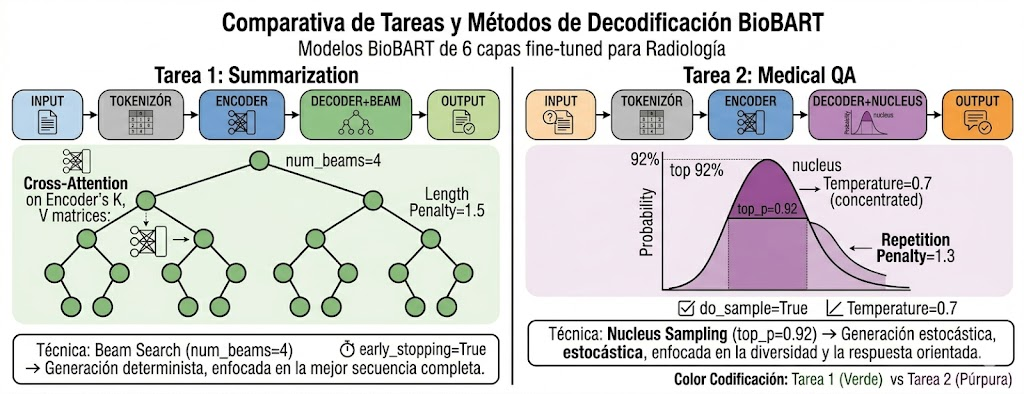

---
## Sección 5 — Hiperparámetros, Conclusiones y Referencias

### 5.1 Resumen de hiperparámetros

## Celda de cierre — Resumen de hiperparámetros y conclusiones

| Hiperparámetro | Tarea 1 (Resumen) | Tarea 2 (QA) | Efecto |
|---|---|---|---|
| `max_new_tokens` | 120 | 150 | Longitud máxima del output generado |
| `num_beams` | 4 | — | Beam Search: explora 4 hipótesis en paralelo |
| `do_sample` | False | True | Beam Search vs. muestreo probabilístico |
| `temperature` | — | 0.7 | Distribución más concentrada: respuestas más seguras |
| `top_k` | — | 50 | Descarta tokens con probabilidad muy baja |
| `top_p` | — | 0.92 | Nucleus: mínimo conjunto que acumula 92% de probabilidad |
| `no_repeat_ngram_size` | 3 | 3 | Prohíbe repetir la misma secuencia de 3 palabras |
| `length_penalty` | 1.5 | — | Premia resúmenes más completos en Beam Search |
| `repetition_penalty` | — | 1.3 | Reduce probabilidad de tokens ya generados |

---

### ¿Por qué no usar Greedy Search en texto clínico?

El Greedy Search elige en cada paso el token con mayor probabilidad
individual (argmax local). En la práctica esto genera tres problemas
concretos en texto médico:

- **Repeticiones**: el token más probable en el paso t suele serlo
  también en t+1, creando bucles como "no acute findings, no acute
  findings, no acute..."
- **Máximos locales**: una elección buena en el paso actual puede
  cerrar caminos globalmente mejores — el resumen final tiene menor
  probabilidad conjunta que el que encontraría Beam Search.
- **Poca diversidad léxica**: los reportes radiológicos generados
  con Greedy tienden a repetir las mismas frases estándar sin
  capturar matices clínicos relevantes.

Beam Search resuelve los dos primeros explorando 4 hipótesis en
paralelo. Nucleus Sampling resuelve el tercero introduciendo
variabilidad controlada. Ambas estrategias mantienen la coherencia
clínica necesaria para que el output sea útil en un entorno médico real.

---

### Reflexión final

Los resultados obtenidos demuestran que BioBART, como modelo
Encoder-Decoder pre-entrenado en PubMed y fine-tuned en reportes
clínicos, puede generar texto médico coherente y estructurado —
tarea imposible para modelos solo-encoder como BioBERT o PubMedBERT.

La elección de la estrategia de decodificación tiene impacto directo
en la calidad del output: Beam Search para resúmenes que exigen
fidelidad factual, Nucleus Sampling para respuestas que requieren
fluidez y variabilidad natural.

### 5.2 Referencias

## Referencias

1. Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N.,
   Kaiser, L., & Polosukhin, I. (2017). *Attention is all you need.*
   Advances in Neural Information Processing Systems, 30.
   https://arxiv.org/abs/1706.03762

2. Lewis, M., Liu, Y., Goyal, N., Ghazvininejad, M., Mohamed, A., Levy, O.,
   Stoyanov, V., & Zettlemoyer, L. (2019). *BART: Denoising sequence-to-sequence
   pre-training for natural language generation, translation, and comprehension.*
   Facebook AI. https://arxiv.org/abs/1910.13461

3. Yuan, H., Yuan, Z., Gan, R., Zhang, J., Xie, Y., & Yu, S. (2022). *BioBART:
   Pretraining and evaluation of a biomedical generative language model.*
   Proceedings of the 21st Workshop on Biomedical Language Processing, BioNLP @ ACL 2022.
   https://aclanthology.org/2022.bionlp-1.9/

4. Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2019). *BERT: Pre-training
   of deep bidirectional transformers for language understanding.*
   Proceedings of NAACL-HLT 2019. https://arxiv.org/abs/1810.04805

5. Malik, H. I. (2023). *Biobart radiology summarization* [Modelo de lenguaje].
   Hugging Face. https://huggingface.co/hamzamalik11/Biobart_radiology_summarization

6. Anthropic. (2025). *Claude* (claude-sonnet-4-6) [Modelo de lenguaje de gran
    escala]. Utilizado como apoyo en la elaboración del desarrollo
    del notebook. https://claude.ai

7. Google DeepMind. (2025). *Gemini* [Modelo de lenguaje de gran escala].
   Utilizado como apoyo en la elaboración del desarrollo del notebook
    https://gemini.google.com